# Import & Settings

In [6]:
import os
import pathlib
import time
import collections
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from util_funcs.metric import score as cmi_score
import random
from torch.utils.data import DataLoader
from miniai.init import *

In [7]:
from torch.optim.lr_scheduler import OneCycleLR
from functools import partial
from miniai.learner import *
from miniai.activations import ActivationStats
from torcheval.metrics import MulticlassAccuracy,MeanSquaredError
from miniai.sgd import BatchSchedCB,RecorderCB,EpochSchedCB
from torch.optim.lr_scheduler import ExponentialLR
from torcheval.metrics import MulticlassAccuracy
from torch.optim import AdamW


In [8]:
SEED = 2025
BASE_DIR = pathlib.Path("data")
OUT_DIR = pathlib.Path(".")
print("output dir:", OUT_DIR)

# data
ID_COL = "sequence_id"
SEQ_COL = "sequence_counter"

TARGET = "gesture"
MAX_LENGTH = 45

# model
NUM_CLASSES = 18
HIDDEN_SIZE = 256
N_LAYERS = 3
N_CLF_LAYERS = 2
BIDIRECTIONAL = True
DROP = 0.15
LABEL_SMOOTHING = 0.1

# trainig
BATCH_SIZE = 200
EPOCHS = 70
LR = 1e-3
LR_MIN = 1e-5
DEVICE = torch.device("cuda")

output dir: .


In [9]:
FEATURES = ['acc_x',
 'acc_y',
 'acc_z',
 'rot_w',
 'rot_x',
 'rot_y',
 'rot_z',
 'thm_1',
 'thm_2',
 'thm_3',
 'thm_4',
 'thm_5']

# Load

In [5]:
path_data = BASE_DIR / "train.csv"
header = pd.read_csv(path_data, nrows=0)
columns = header.columns
columns = [x for x in columns]

columns

['row_id',
 'sequence_type',
 'sequence_id',
 'sequence_counter',
 'subject',
 'orientation',
 'behavior',
 'phase',
 'gesture',
 'acc_x',
 'acc_y',
 'acc_z',
 'rot_w',
 'rot_x',
 'rot_y',
 'rot_z',
 'thm_1',
 'thm_2',
 'thm_3',
 'thm_4',
 'thm_5',
 'tof_1_v0',
 'tof_1_v1',
 'tof_1_v2',
 'tof_1_v3',
 'tof_1_v4',
 'tof_1_v5',
 'tof_1_v6',
 'tof_1_v7',
 'tof_1_v8',
 'tof_1_v9',
 'tof_1_v10',
 'tof_1_v11',
 'tof_1_v12',
 'tof_1_v13',
 'tof_1_v14',
 'tof_1_v15',
 'tof_1_v16',
 'tof_1_v17',
 'tof_1_v18',
 'tof_1_v19',
 'tof_1_v20',
 'tof_1_v21',
 'tof_1_v22',
 'tof_1_v23',
 'tof_1_v24',
 'tof_1_v25',
 'tof_1_v26',
 'tof_1_v27',
 'tof_1_v28',
 'tof_1_v29',
 'tof_1_v30',
 'tof_1_v31',
 'tof_1_v32',
 'tof_1_v33',
 'tof_1_v34',
 'tof_1_v35',
 'tof_1_v36',
 'tof_1_v37',
 'tof_1_v38',
 'tof_1_v39',
 'tof_1_v40',
 'tof_1_v41',
 'tof_1_v42',
 'tof_1_v43',
 'tof_1_v44',
 'tof_1_v45',
 'tof_1_v46',
 'tof_1_v47',
 'tof_1_v48',
 'tof_1_v49',
 'tof_1_v50',
 'tof_1_v51',
 'tof_1_v52',
 'tof_1_v53',
 'tof

In [33]:
data = pd.read_csv(path_data, usecols=columns)
data.shape

(574945, 341)

In [34]:
tof_cols =[x for x in header.columns if x.startswith("tof")]
data[tof_cols].head(5)

,tof_1_v0,tof_1_v1,tof_1_v2,tof_1_v3,tof_1_v4,tof_1_v5,tof_1_v6,tof_1_v7,tof_1_v8,tof_1_v9,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,131.0,134.0,132.0,135.0,98.0,74.0,64.0,60.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,130.0,138.0,131.0,135.0,101.0,76.0,66.0,61.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,137.0,136.0,147.0,109.0,90.0,81.0,74.0,74.0,-1.0,164.0,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,143.0,147.0,170.0,127.0,109.0,98.0,95.0,95.0,-1.0,177.0,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,178.0,191.0,183.0,157.0,146.0,139.0,143.0,148.0,-1.0,-1.0,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0


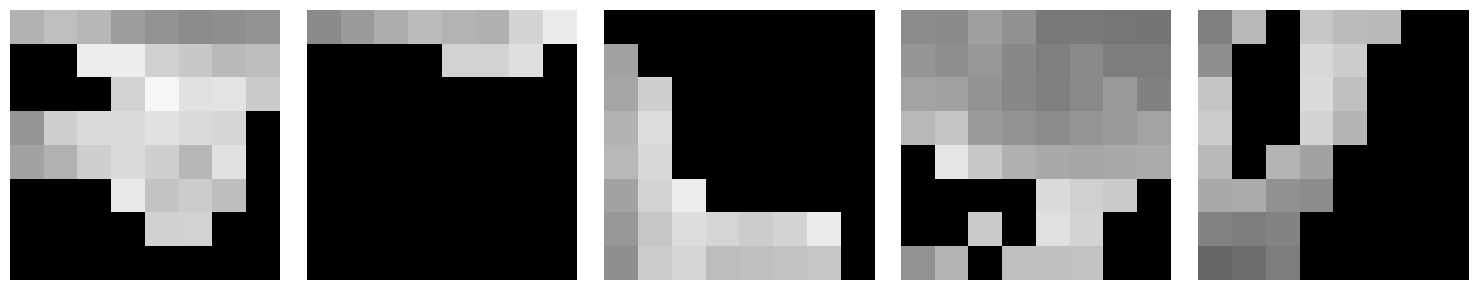

orientation              Seated Lean Non Dom - FACE DOWN
behavior       Relaxes and moves hand to target location
Name: 4, dtype: object


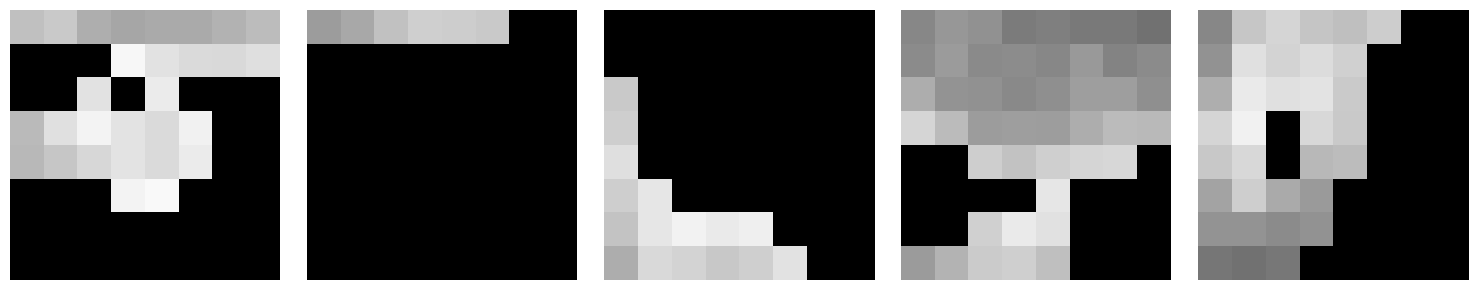

orientation              Seated Lean Non Dom - FACE DOWN
behavior       Relaxes and moves hand to target location
Name: 5, dtype: object


(None, None)

In [ ]:
### Displaying the first few rows of the tof data

from util_funcs.helper_funcs import display_multiple_images

display_multiple_images(data[tof_cols].loc[4]),print(data[["orientation",'behavior']].loc[4])
display_multiple_images(data[tof_cols].loc[5]),print(data[["orientation",'behavior']].loc[5])

-Get random sequence and display the values of the tof with the orientation and behaviour for the single sequence


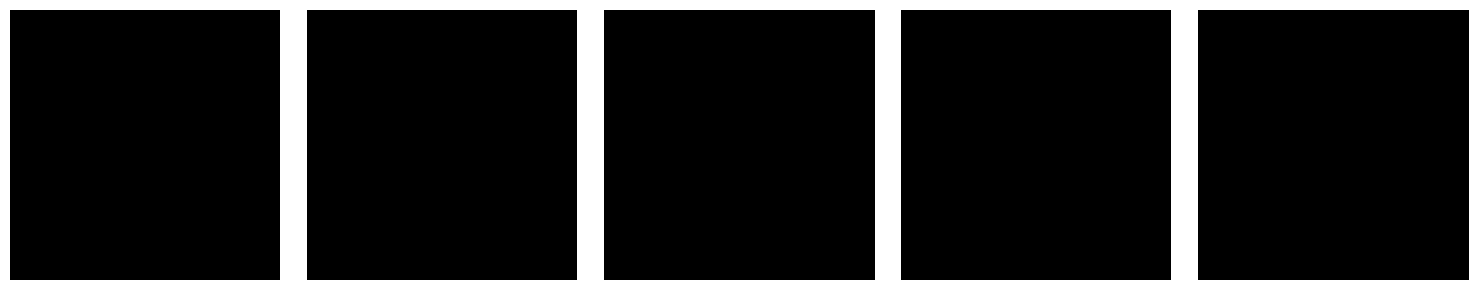

orientation                   Lie on Side - Non Dominant
behavior       Relaxes and moves hand to target location
Name: 0, dtype: object


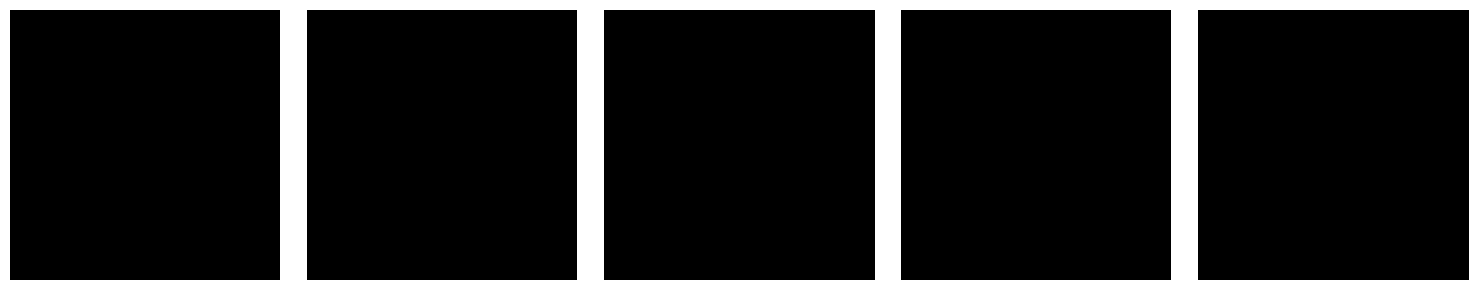

orientation                   Lie on Side - Non Dominant
behavior       Relaxes and moves hand to target location
Name: 1, dtype: object


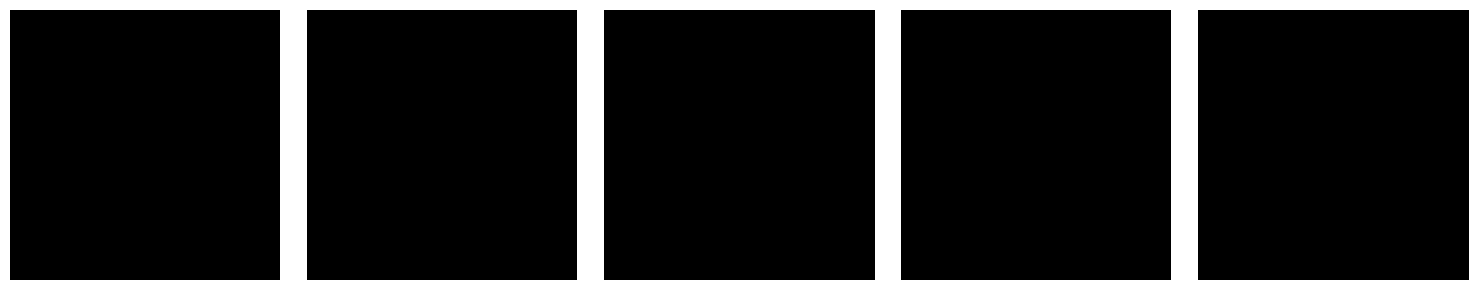

orientation                   Lie on Side - Non Dominant
behavior       Relaxes and moves hand to target location
Name: 2, dtype: object


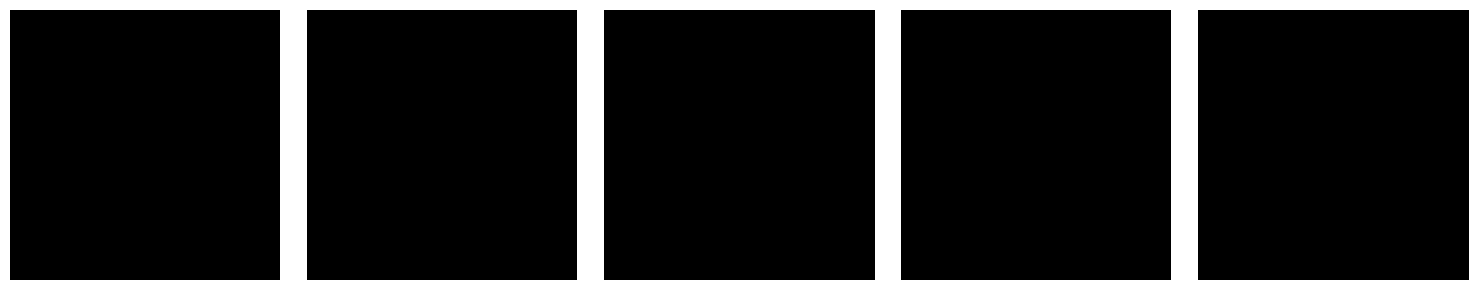

orientation                   Lie on Side - Non Dominant
behavior       Relaxes and moves hand to target location
Name: 3, dtype: object


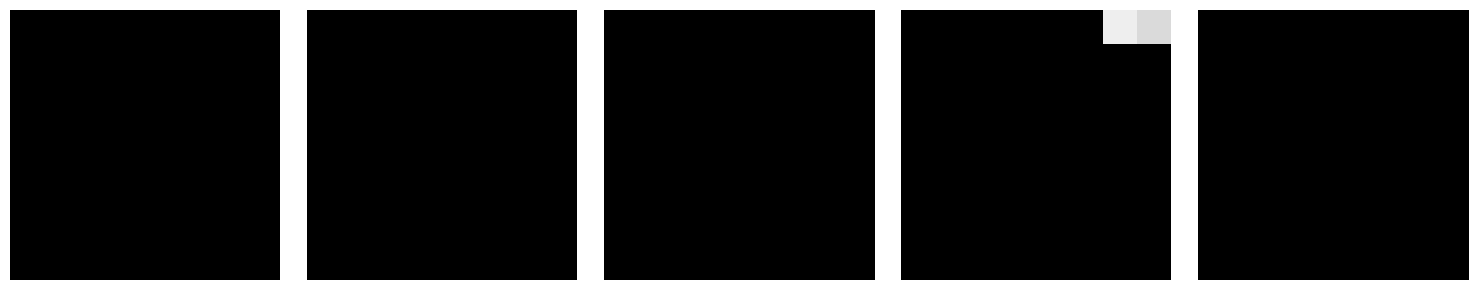

orientation                   Lie on Side - Non Dominant
behavior       Relaxes and moves hand to target location
Name: 4, dtype: object


In [ ]:
import random
sequence_id = random.choice(list(data.sequence_id.unique()))
truncated_sequence_df = data[data["sequence_id"]==sequence_id].tail(MAX_LENGTH).reset_index()
for i in range(5):
    display_multiple_images(truncated_sequence_df[tof_cols].loc[i]),print(truncated_sequence_df[["orientation","behavior"]].loc[i])

### Reshaping the tof data into a single image



In [21]:
single_row = data[tof_cols].iloc[0].values

In [27]:
import math
math.sqrt(320)


17.88854381999832

In [26]:
ADDED_PADDING = 4
import torch
from torch.nn import functional
import torch.nn as nn
single_row = torch.from_numpy(single_row)
reshape_tof_row = lambda tof_row: torch.reshape(functional.pad(tof_row,(0,ADDED_PADDING)),(18,18))
reshaped = torch.reshape(functional.pad(single_row,(0,ADDED_PADDING)),(18,18))

In [514]:
seq_ids = [random.choice(list(data.sequence_id.unique())) for _ in range(3)] 

In [37]:
sequence_id = random.choice(list(data.sequence_id.unique()))
seq_df_tof = data[data.sequence_id==sequence_id][tof_cols].values
converted_tensor = [reshape_tof_row(torch.from_numpy(row)) \
                    for row in seq_df_tof]
#this will suffice as an experiment

In [516]:
sequence_ids = list(data.sequence_id.unique())

lists_of_dfs = [data[data.sequence_id==sequence_id][tof_cols].values for sequence_id in sequence_ids[:100]]


In [517]:
converted_tensor = [[reshape_tof_row(torch.from_numpy(df_row)) for df_row in seq_df] for seq_df in lists_of_dfs]

In [518]:
minified_tensor = [tens for tens in converted_tensor[0:30]]

In [519]:
flattened_tensor =[element for sublist in minified_tensor for element in sublist]

In [427]:
def reverse_conv(ni,nf,stride=1,ks=3,sample_scale=2):
    layer = [nn.UpsamplingNearest2d(scale_factor=sample_scale)]
    layer.append(nn.Conv2d(ni,nf,stride=stride,kernel_size=ks,padding=ks//2))
    return nn.Sequential(*layer)

In [ ]:
#z score scaling for now

stacked_tensor = torch.nan_to_num(torch.stack(flattened_tensor).float(),nan=0.0)
flattened_stacked = stacked_tensor.view(stacked_tensor.shape[0],-1)
flattened_stacked = torch.clamp(flattened_stacked,min=-1e-6)
data_mean = flattened_stacked.mean((0,1))
data_std = flattened_stacked.std((0,1)) #just demonstrating that they're the same thing


standardized_tensor = torch.sigmoid((stacked_tensor-data_mean)/data_std)

In [570]:
with torch.no_grad():
    result = model(standardized_tensor[0][None,None,:].float().to("cuda"))
result.shape
#

torch.Size([1, 1, 18, 18])

In [571]:
F.mse_loss(result,standardized_tensor[0][None,None,:].float().to("cuda"))

tensor(0.8363, device='cuda:0')

In [537]:
"""Steps to do right now:
- Add relus for now and batchnorm along with kaiming her init.
- Get a batch of data and do a training run, monitor the training stats to see what will happen"""

'Steps to do right now:\n- Add relus for now and batchnorm along with kaiming her init.\n- Get a batch of data and do a training run, monitor the training stats to see what will happen'

In [603]:
def collate_fn(entire_tensor):
    x_tensors= y_tensors = torch.stack(entire_tensor)
    standardized_x, standardized_y =torch.sigmoid((x_tensors-data_mean)/data_std),torch.sigmoid((y_tensors-data_mean)/data_std)

    return standardized_x.unsqueeze(1).float(), standardized_y.unsqueeze(1).float()

In [638]:
dls = DataLoader(stacked_tensor,batch_size=50,collate_fn=collate_fn,shuffle=False)
x_batch,y_batch = next(iter(dls))

In [639]:

stride = 2
ks = 3
padding = ks//2
model = nn.Sequential(nn.Conv2d(1,8, stride=stride, kernel_size=ks, padding=ks//2),GeneralRelu(leak=0.4,sub=0.1),nn.BatchNorm2d(num_features=8), #9x9
                      nn.Conv2d(8,16, stride=stride, kernel_size=ks, padding=ks//2),GeneralRelu(leak=0.4,sub=0.1),nn.BatchNorm2d(num_features=16),
                      reverse_conv(16,8),GeneralRelu(leak=0.4,sub=0.1),nn.BatchNorm2d(num_features=8),
                      reverse_conv(8,1),nn.ZeroPad2d(-1))
model.apply(init_weights)

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): GeneralRelu()
  (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): GeneralRelu()
  (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Sequential(
    (0): UpsamplingNearest2d(scale_factor=2.0, mode='nearest')
    (1): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (7): GeneralRelu()
  (8): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): Sequential(
    (0): UpsamplingNearest2d(scale_factor=2.0, mode='nearest')
    (1): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (10): ZeroPad2d((-1, -1, -1, -1))
)

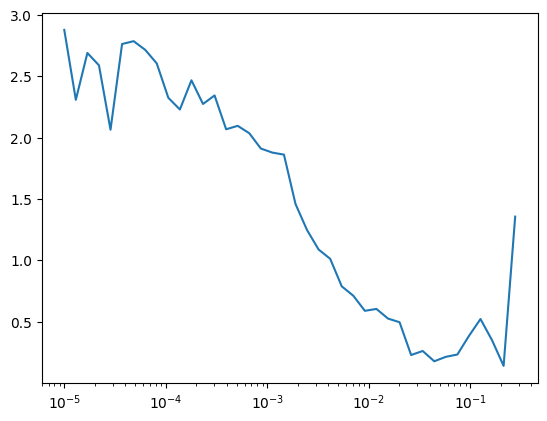

In [ ]:
from miniai.learner import *
from miniai.datasets import DataLoaders
acts = ActivationStats(GeneralRelu)
fastai_dls = DataLoaders(dls,dls)
cbs = [DeviceCB(),ProgressCB(plot=False),TrainCB(n_inp=1),acts]

autoconv_learner = Learner(model,fastai_dls,loss_func=F.mse_loss,cbs=cbs,opt_func=AdamW)

autoconv_learner.lr_find()

In [641]:
from copy import copy
from torcheval.metrics import MulticlassAccuracy,Mean
class MetricsCB_M(Callback):
    def __init__(self,*ms,**metrics):
    
        for o in ms: metrics[type(o).__name__]=o    
        self.metrics = metrics
        self.all_metrics = copy(metrics)
        self.all_metrics["loss"] = self.loss = Mean()

    def log_(self,item): print(item)

    def before_fit(self,learn): learn.metrics= self

    def before_epoch(self,learn):
        
        [o.reset() for o in self.all_metrics.values()]

    def after_batch(self,learn):
        x,y,*_ = to_cpu(learn.batch)
        for m in self.metrics.values():
            m.update(to_cpu(learn.preds.mean((0,1))),y.mean((0,1)))
        self.loss.update(to_cpu(learn.loss),weight=len(x))

    def after_epoch(self,learn):
        logs = {k:f"{v.compute():.3f}" for k,v in self.all_metrics.items()}
        logs["train"]="train" if learn.model.training else "valid"
        logs["epoch"] = learn.epoch
        self.log_(logs)

In [ ]:
fit_cbs = cbs.extend([MetricsCB_M(MeanSquaredError())])
autoconv_learner.fit(5,lr=1e-4,cbs = fit_cbs)


{'MeanSquaredError': '0.289', 'loss': '0.530', 'train': 'train', 'epoch': 0}
{'MeanSquaredError': '0.514', 'loss': '0.762', 'train': 'valid', 'epoch': 0}
{'MeanSquaredError': '0.170', 'loss': '0.306', 'train': 'train', 'epoch': 1}
{'MeanSquaredError': '0.249', 'loss': '0.384', 'train': 'valid', 'epoch': 1}
{'MeanSquaredError': '0.099', 'loss': '0.183', 'train': 'train', 'epoch': 2}
{'MeanSquaredError': '0.120', 'loss': '0.203', 'train': 'valid', 'epoch': 2}
{'MeanSquaredError': '0.062', 'loss': '0.122', 'train': 'train', 'epoch': 3}
{'MeanSquaredError': '0.064', 'loss': '0.123', 'train': 'valid', 'epoch': 3}
{'MeanSquaredError': '0.045', 'loss': '0.093', 'train': 'train', 'epoch': 4}
{'MeanSquaredError': '0.041', 'loss': '0.090', 'train': 'valid', 'epoch': 4}


### Training done, let's write the inference code



In [682]:
torch.save(model.state_dict(),"models/tof_autoencoder.pth")

In [ ]:
encoder = model[:6]

In [711]:
preprocess_tof_tens = lambda tens:torch.sigmoid((tens-data_mean)/data_std).unsqueeze(1).float()

In [679]:
encoder_with_pooling = nn.Sequential(encoder,nn.AdaptiveAvgPool2d((1,1)))

In [688]:
torch.save(encoder_with_pooling.state_dict(),"models/tof_encoder.pth")

In [700]:
data_tof = torch.from_numpy(data[tof_cols].values)
reshaped_data_tof = [reshape_tof_row(tof_row) for tof_row in data_tof]
reshaped_tof_rows = torch.stack(reshaped_data_tof)
stacked_tensor = torch.nan_to_num(reshaped_tof_rows.float(),nan=0.0)
flattened_stacked = stacked_tensor.view(stacked_tensor.shape[0],-1)
flattened_stacked = torch.clamp(flattened_stacked,min=-1e-6)

In [705]:
stacked_tensor = torch.clamp(stacked_tensor,min=-1e-6)


In [ ]:
entire_data_tensor = stacked_tensor


In [710]:
entire_data_tensor.shape

torch.Size([574945, 18, 18])

In [712]:
#applying this encoding to the entire dataframe
with torch.no_grad():

    output_features = encoder_with_pooling(preprocess_tof_tens(entire_data_tensor).to("cuda"))

In [736]:
flattened = output_features.view(output_features.size(0), -1).to("cpu")

In [ ]:
encoder = nn.Sequential(*encoder,nn.AdaptiveAvgPool2d())

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): GeneralRelu()
  (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): GeneralRelu()
  (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

In [726]:
assert NUM_CLASSES == len(cat.categories)
print(f"#{NUM_CLASSES} classes found.")

#18 classes found.


# Split

In [727]:
def add_split(data):
    data["split"] = -1
    df = data[[ID_COL, TARGET]].value_counts().reset_index()[[ID_COL, TARGET]].reset_index(drop=True)
    splitter = StratifiedKFold(shuffle=True, random_state=SEED)
    for i, (__, i_valid) in enumerate(splitter.split(df, y=df[TARGET])):
        ind = df.iloc[i_valid].index
        ids = df.loc[ind][ID_COL].values
        ind = data[data[ID_COL].isin(ids)].index
        data.loc[ind, "split"] = i

In [728]:
add_split(data)

In [738]:
splits = {}
for x in sorted(data["split"].unique()):
    splits[f"split_{x}"] = data[data["split"] == x].groupby(ID_COL)[TARGET].first().value_counts()
pd.DataFrame(splits)

,split_0,split_1,split_2,split_3,split_4
gesture,,,,,
0,128,127,127,128,128
1,127,128,128,127,127
2,32,32,32,33,32
3,127,127,128,128,128
4,128,128,128,128,128
5,33,32,32,32,32
6,128,128,128,128,128
7,128,128,128,128,128
8,32,32,32,33,32


In [ ]:
flattened

In [742]:
tof_features = ["tof_feature_{}".format(idx) for idx in range(flattened.shape[1])]

tof_features

['tof_feature_0',
 'tof_feature_1',
 'tof_feature_2',
 'tof_feature_3',
 'tof_feature_4',
 'tof_feature_5',
 'tof_feature_6',
 'tof_feature_7',
 'tof_feature_8',
 'tof_feature_9',
 'tof_feature_10',
 'tof_feature_11',
 'tof_feature_12',
 'tof_feature_13',
 'tof_feature_14',
 'tof_feature_15']

In [743]:
data[tof_features] = flattened

In [744]:
ind_train = data[data["split"] != 0].index
ind_valid = data[data["split"] == 0].index
train = data.loc[ind_train].copy()
valid = data.loc[ind_valid].copy()
len(train), len(valid)

(461063, 113882)

In [745]:
ids_train = train[ID_COL].unique()
ids_valid = valid[ID_COL].unique()
len(ids_train), len(ids_valid), set(ids_valid).isdisjoint(ids_train)

(6520, 1631, True)

# Focus on a single fold

In [747]:
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [748]:
train.columns

Index(['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject',
       'orientation', 'behavior', 'phase', 'gesture', 'acc_x',
       ...
       'tof_feature_6', 'tof_feature_7', 'tof_feature_8', 'tof_feature_9',
       'tof_feature_10', 'tof_feature_11', 'tof_feature_12', 'tof_feature_13',
       'tof_feature_14', 'tof_feature_15'],
      dtype='object', length=358)

In [749]:
transformer = ColumnTransformer(
    transformers=[
        (
            "pipe",
            Pipeline([("im", SimpleImputer()), ("sc", StandardScaler())]),
            FEATURES,
        )
    ],
    # remainder="passthrough",
    verbose_feature_names_out=False,
)
transformer.set_output(transform="pandas")
transformer.fit(train)

ColumnTransformer(transformers=[('pipe',
                                 Pipeline(steps=[('im', SimpleImputer()),
                                                 ('sc', StandardScaler())]),
                                 ['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x',
                                  'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3',
                                  'thm_4', 'thm_5'])],
                  verbose_feature_names_out=False)

In [750]:
train.loc[11111].to_dict()

{'row_id': 'SEQ_001160_000001',
 'sequence_type': 'Target',
 'sequence_id': 'SEQ_001160',
 'sequence_counter': 1,
 'subject': 'SUBJ_058967',
 'orientation': 'Lie on Side - Non Dominant',
 'behavior': 'Relaxes and moves hand to target location',
 'phase': 'Transition',
 'gesture': 1,
 'acc_x': 4.21875,
 'acc_y': -0.40234375,
 'acc_z': -9.09375,
 'rot_w': nan,
 'rot_x': nan,
 'rot_y': nan,
 'rot_z': nan,
 'thm_1': 26.488784790039062,
 'thm_2': 26.12098693847656,
 'thm_3': 26.87885856628418,
 'thm_4': 27.016286849975582,
 'thm_5': 26.47159576416016,
 'tof_1_v0': 102.0,
 'tof_1_v1': 91.0,
 'tof_1_v2': 96.0,
 'tof_1_v3': 94.0,
 'tof_1_v4': 68.0,
 'tof_1_v5': 54.0,
 'tof_1_v6': 52.0,
 'tof_1_v7': 50.0,
 'tof_1_v8': -1.0,
 'tof_1_v9': 97.0,
 'tof_1_v10': 99.0,
 'tof_1_v11': 93.0,
 'tof_1_v12': 74.0,
 'tof_1_v13': 62.0,
 'tof_1_v14': 55.0,
 'tof_1_v15': 52.0,
 'tof_1_v16': -1.0,
 'tof_1_v17': 106.0,
 'tof_1_v18': 96.0,
 'tof_1_v19': 90.0,
 'tof_1_v20': 73.0,
 'tof_1_v21': 67.0,
 'tof_1_v22': 6

In [751]:
train[FEATURES] = transformer.transform(train[FEATURES])
valid[FEATURES] = transformer.transform(valid[FEATURES])
train.loc[11111].to_dict()

{'row_id': 'SEQ_001160_000001',
 'sequence_type': 'Target',
 'sequence_id': 'SEQ_001160',
 'sequence_counter': 1,
 'subject': 'SUBJ_058967',
 'orientation': 'Lie on Side - Non Dominant',
 'behavior': 'Relaxes and moves hand to target location',
 'phase': 'Transition',
 'gesture': 1,
 'acc_x': 0.44377547985309157,
 'acc_y': -0.43553074774512546,
 'acc_z': -1.4202695632672877,
 'rot_w': -2.463057714603856e-16,
 'rot_x': 0.0,
 'rot_y': -1.2805991159652866e-17,
 'rot_z': 0.0,
 'thm_1': -0.1781223121037624,
 'thm_2': -0.34248209465093454,
 'thm_3': 0.041577121658952644,
 'thm_4': -0.24119164613942223,
 'thm_5': -0.08235556039500525,
 'tof_1_v0': 102.0,
 'tof_1_v1': 91.0,
 'tof_1_v2': 96.0,
 'tof_1_v3': 94.0,
 'tof_1_v4': 68.0,
 'tof_1_v5': 54.0,
 'tof_1_v6': 52.0,
 'tof_1_v7': 50.0,
 'tof_1_v8': -1.0,
 'tof_1_v9': 97.0,
 'tof_1_v10': 99.0,
 'tof_1_v11': 93.0,
 'tof_1_v12': 74.0,
 'tof_1_v13': 62.0,
 'tof_1_v14': 55.0,
 'tof_1_v15': 52.0,
 'tof_1_v16': -1.0,
 'tof_1_v17': 106.0,
 'tof_1_v18'

In [145]:
joblib.dump(transformer, OUT_DIR / "preprocessing.joblib")

['preprocessing.joblib']

# Dataset & Dataloader
- Note that we ultimately want to have the input to be of the form ``[seq, batch, feature]``.
- Mask is only of size ``[seq, batch]``.

In [752]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [753]:
d_data = dict(list(data.groupby(ID_COL)))

In [758]:
#appending the tof features to the features list now

FEATURES.extend(tof_features)

In [759]:
class CMIData(Dataset):
    def __init__(self, data, max_length=None):
        super().__init__()
        self.d_data = dict(list(data.groupby(ID_COL)))
        self.features = FEATURES
        self.target = TARGET
        self.max_length = max_length
        self.keys = list(self.d_data)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, index):
        df = self.d_data[self.keys[index]]
        if self.max_length is not None:
            df = df.iloc[-self.max_length :]
        return (
            torch.tensor(df[self.features].values.astype(np.float32)),
            torch.tensor(df[self.target].values[-1].astype(np.int64)),
        )

In [760]:
ds = CMIData(train, max_length=10)


In [762]:
def collate_fn(batch):
    x_tensors = [item[0] for item in batch]
    y_tensors = [item[1] for item in batch]
    
    batch_x = pad_sequence(x_tensors, batch_first=False, padding_value=0.0)
    batch_y = torch.tensor(y_tensors)
    # mask = pad_sequence(
    #     [torch.ones_like(x[..., -1]) for x in x_tensors], padding_value=0
    # )
    return batch_x,batch_y

In [763]:
ds = CMIData(train, max_length=100)
dl = DataLoader(ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
x, y = next(iter(dl))
x.shape, y.shape

(torch.Size([57, 2, 28]), torch.Size([2]))

# Model
Start with the following architecture:
- input passes thru LSTM layers
- compute mean over all hidden states respecting mask
- apply dropout
- use output classifier to get logits

In [764]:
"""We need the following:- the architecutre that we have is going to be an lstm followed by a fully connected layer, a relu (I highly doubt that 
I am not going to change that, and a another linear layer that reshapes the output to correspond to the amounts of outputs that we have)
- a loss function, cross entropy loss.
- a dropout layer.
- a layer norm layer (to be added later on).
- some mechanism to determine the most optimal learning rate.
- I also want to investigate the hidden state size it just seems super arbitrary."""

'We need the following:- the architecutre that we have is going to be an lstm followed by a fully connected layer, a relu (I highly doubt that \nI am not going to change that, and a another linear layer that reshapes the output to correspond to the amounts of outputs that we have)\n- a loss function, cross entropy loss.\n- a dropout layer.\n- a layer norm layer (to be added later on).\n- some mechanism to determine the most optimal learning rate.\n- I also want to investigate the hidden state size it just seems super arbitrary.'

In [765]:
inpt_size = 57.
hidden_size=256
num_layers = 3
bias=True
batch_first=True
bidirectonal=True
CLASS_NOS = 18

In [766]:
lstm = nn.LSTM(input_size =28,
    hidden_size=hidden_size,
    num_layers = num_layers,
    bias=True,
    batch_first=False,
    bidirectional=True)
CLFs = nn.Sequential(*[nn.Linear(hidden_size*2,hidden_size),
nn.Dropout(p=0.05),
nn.ReLU(),
nn.Linear(hidden_size,CLASS_NOS)])

In [27]:
with torch.no_grad():
    logitss= lstm(x)

In [11]:
class GeneralRelu(nn.Module):
    def __init__(self, leak=None, sub=None, maxv=None):
        super().__init__()
        self.leak,self.sub,self.maxv = leak,sub,maxv

    def forward(self, x): 
        x = F.leaky_relu(x,self.leak) if self.leak is not None else F.relu(x)
        if self.sub is not None: x -= self.sub
        if self.maxv is not None: x.clamp_max_(self.maxv)
        return x


In [10]:
import torch.nn.init as init
from functools import partial




class LayerNorm_M(nn.Module):
    def __init__(self, hidden_size=256, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(1,1, hidden_size))  # scale
        self.beta = nn.Parameter(torch.zeros(1,1, hidden_size))  # shift

    def forward(self, x):
        # x shape: [num_layers, batch_size, hidden_size]
        mean = x.mean(dim=-1, keepdim=True)  # mean over hidden_size
        std = x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta
import torch
import torch.nn as nn
from torch.nn import LayerNorm


class LSTMClassifier(nn.Module):
    def __init__(self, input_size=28, hidden_size=256, num_layers=1, bidirectional=True, num_classes=18):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Create LSTM layers and layer norms manually
        self.lstm_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()

        for layer in range(num_layers):
            lstm_input_size = input_size if layer == 0 else hidden_size * self.num_directions
            lstm_layer = nn.LSTM(input_size=lstm_input_size,
                        hidden_size=hidden_size,
                        num_layers=1,
                        bidirectional=bidirectional,
                        dropout=0.2,
                        batch_first=False)
            self.lstm_layers.append(
               lstm_layer
            )
            for name, param in lstm_layer.named_parameters():
                if 'weight' in name:  # Apply only to weights, not biases
                    init.xavier_normal_(param)
            self.layer_norms.append(LayerNorm(hidden_size * self.num_directions))

        self.dropout = nn.Dropout(p=0.3)
        # self.leaky_act = GeneralRelu(leak=0.4, sub=0.1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * self.num_directions, hidden_size),
            GeneralRelu(leak=0.4, sub=0.1),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        out = x  # (seq_len, batch, input_size)
        h_n = None
        for i, (lstm, norm) in enumerate(zip(self.lstm_layers, self.layer_norms)):
            out, (h_n, _) = lstm(out)   # out: (seq_len, batch, hidden*2), h_n: (num_directions, batch, hidden)
            out = norm(out)

        # Get final hidden state from last layer
        # h_n: (num_directions, batch, hidden_size)
        h_final = h_n.transpose(0, 1).contiguous().view(x.size(1), -1)  # (batch, hidden_size * num_directions)

        h_final = self.dropout(h_final)
        return self.classifier(h_final)


In [12]:
"""Prepping the data loaders for training and validation sets."""
from miniai.datasets import DataLoaders
import fastcore.all as fc
train_dset = CMIData(train,max_length =55)
valid_dset = CMIData(valid,max_length =55)

train_dls = DataLoader(train_dset,batch_size=100,collate_fn=collate_fn)
valid_dls = DataLoader(valid_dset,batch_size=100,collate_fn=collate_fn)
entire_dls = DataLoaders(train_dls,valid_dls)

NameError: name 'CMIData' is not defined

In [866]:
from importlib import reload
from miniai import learner
reload(learner)

<module 'miniai.learner' from 'c:\\Users\\Moetasim Rady\\Desktop\\course22p2\\fastaiEnv\\lib\\site-packages\\miniai\\learner.py'>

In [870]:
def initialize_weights(module):
    if isinstance(module, nn.Linear):  # Apply to Linear layers
        init.kaiming_normal_(module.weight, nonlinearity='relu')
        if module.bias is not None:
            init.zeros_(module.bias)

In [895]:
import math
from torch.optim.lr_scheduler import OneCycleLR
from functools import partial
from miniai.learner import *
import fastcore.all as fc
from miniai.activations import ActivationStats
from torcheval.metrics import MulticlassAccuracy
from miniai.sgd import BatchSchedCB,RecorderCB,EpochSchedCB
from torch.optim.lr_scheduler import ExponentialLR
from torcheval.metrics import MulticlassAccuracy
from torch.optim import AdamW
class LRFinderCB(Callback):
    def __init__(self, gamma=1.3, max_mult=3): fc.store_attr()
    
    def before_fit(self, learn):

        self.sched = ExponentialLR(learn.opt, self.gamma)
        self.lrs,self.losses = [],[]
        self.min = math.inf

    def after_batch(self, learn):
        if not learn.training: raise CancelEpochException()
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        loss = to_cpu(learn.loss)
        self.losses.append(loss)
        if loss < self.min: self.min = loss
        if math.isnan(loss) or (loss > self.min*self.max_mult):
            raise CancelFitException()
        self.sched.step()

    def cleanup_fit(self, learn):
        plt.plot(self.lrs, self.losses)
        plt.xscale('log')
lr = 1e-2


acts_hook = ActivationStats(mod_filter=fc.risinstance(GeneralRelu))
cbs = [DeviceCB(),MetricsCB_M(accuracy=MulticlassAccuracy()),TrainCB(n_inp=1),ProgressCB(plot=True)]
all_cbs = [acts_hook]
model = LSTMClassifier()
model.apply(initialize_weights)

n_steps = len(entire_dls.train) * EPOCHS
lr_sched = partial(OneCycleLR,total_steps=n_steps)
sched_cb = BatchSchedCB(sched=lr_sched)
train_obj =TrainCB(n_inp=1);train_obj.order=10 #setting priority for traincb
learn=Learner(model,dls=entire_dls,loss_func = F.cross_entropy,cbs=cbs,opt_func=AdamW)

straya mate


c:\Users\Moetasim Rady\Desktop\course22p2\fastaiEnv\lib\site-packages\torch\nn\modules\rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


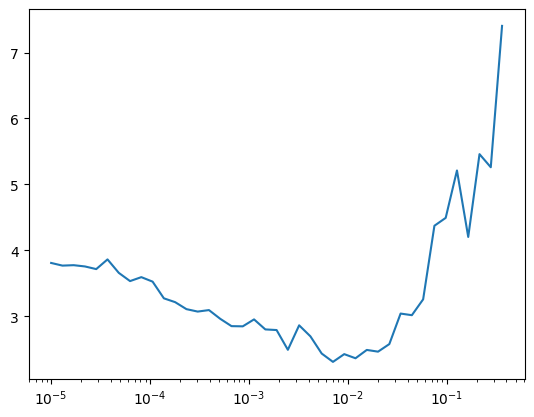

In [857]:
learn.lr_find(start_lr=1e-5)

In [14]:
import joblib
joblib.dump(transformer, OUT_DIR / "second_preprocessing.joblib")

NameError: name 'transformer' is not defined

{'accuracy': '0.133', 'loss': '2.980', 'train': 'train', 'epoch': 0}
{'accuracy': '0.222', 'loss': '2.445', 'train': 'valid', 'epoch': 0}


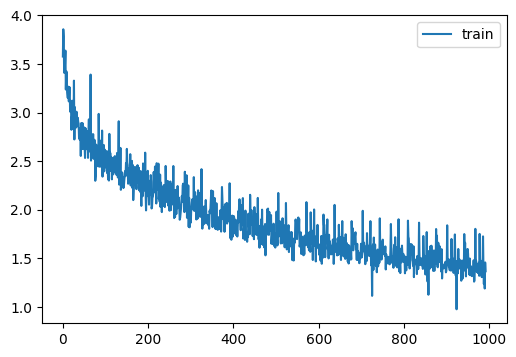

{'accuracy': '0.214', 'loss': '2.542', 'train': 'train', 'epoch': 1}
{'accuracy': '0.281', 'loss': '2.255', 'train': 'valid', 'epoch': 1}
{'accuracy': '0.259', 'loss': '2.323', 'train': 'train', 'epoch': 2}
{'accuracy': '0.318', 'loss': '2.118', 'train': 'valid', 'epoch': 2}
{'accuracy': '0.290', 'loss': '2.185', 'train': 'train', 'epoch': 3}
{'accuracy': '0.337', 'loss': '2.018', 'train': 'valid', 'epoch': 3}
{'accuracy': '0.311', 'loss': '2.060', 'train': 'train', 'epoch': 4}
{'accuracy': '0.354', 'loss': '1.929', 'train': 'valid', 'epoch': 4}
{'accuracy': '0.330', 'loss': '1.951', 'train': 'train', 'epoch': 5}
{'accuracy': '0.368', 'loss': '1.850', 'train': 'valid', 'epoch': 5}
{'accuracy': '0.349', 'loss': '1.862', 'train': 'train', 'epoch': 6}
{'accuracy': '0.368', 'loss': '1.782', 'train': 'valid', 'epoch': 6}
{'accuracy': '0.367', 'loss': '1.780', 'train': 'train', 'epoch': 7}
{'accuracy': '0.400', 'loss': '1.718', 'train': 'valid', 'epoch': 7}
{'accuracy': '0.385', 'loss': '1.7

KeyboardInterrupt: 

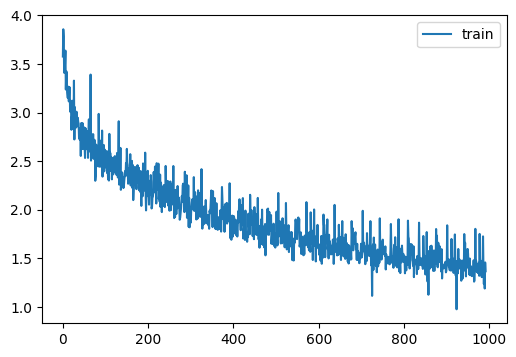

In [896]:
learn.fit(30,cbs=all_cbs,lr=1e-4)

- ooo wee look at me I've successfully attached the activations callback to monitor the inner activations of the model.
Now let's take a look at them.

In [897]:
acts_hook.hooks = [hook for hook in acts_hook.hooks if hasattr(hook, 'stats')]

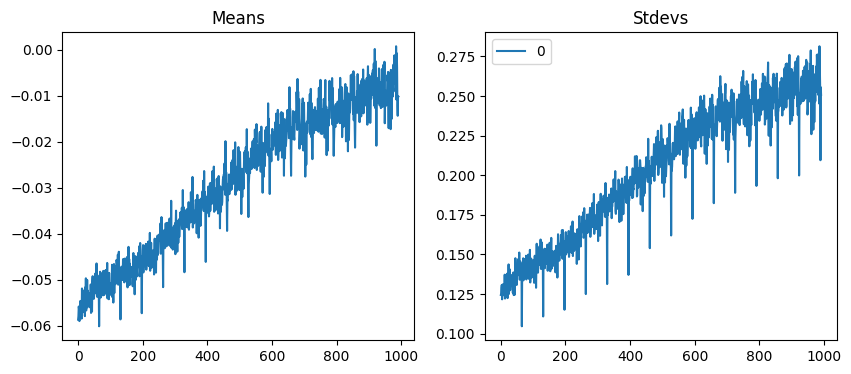

In [900]:

acts_hook.plot_stats()

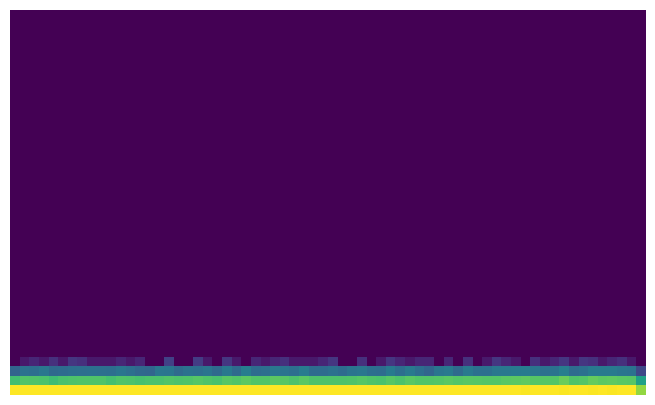

In [885]:
acts_hook.color_dim()

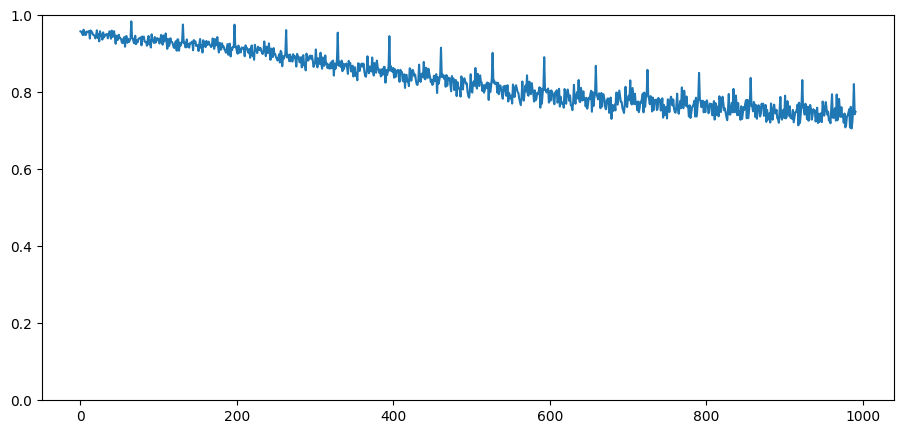

In [901]:
acts_hook.dead_chart()

In [139]:
#still not what I am looking for.

# Training

In [101]:
ds_train = CMIData(train, max_length=MAX_LENGTH)
train_loader = DataLoader(
    ds_train, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn, 
    drop_last=True
)
print(f"Training dataset contains: {len(ds_train)}")
ds_valid = CMIData(valid, max_length=MAX_LENGTH)
valid_loader = DataLoader(
    ds_valid,
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    drop_last=True,
)
print(f"Valid dataset contains: {len(ds_valid)}")

Training dataset contains: 6520
Valid dataset contains: 1631


In [139]:
model = LSTMClassifier().to(DEVICE)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=10, min_lr=LR_MIN
)

c:\Users\Moetasim Rady\Desktop\course22p2\fastaiEnv\lib\site-packages\torch\nn\modules\rnn.py:71: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [80]:
def evalute(model, data_loader, loss_fn):
    model.eval()
    loss = 0.0
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            loss += loss_fn(logits, y).item()
    model.train()
    return loss / len(data_loader)

In [908]:
def predict(model, data):
    model.eval()
    ds = CMIData(data, max_length=55)
    dl = DataLoader(
        ds, shuffle=False, batch_size=BATCH_SIZE, collate_fn=collate_fn, drop_last=False
    )
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            y_pred.append(torch.argmax(logits, dim=-1).cpu().numpy())
            y_true.append(y.cpu().numpy())
    sol = pd.DataFrame(
        {"id": ds.keys, "gesture": cat.categories[np.concatenate(y_true)].values}
    )
    sub = pd.DataFrame(
        {"id": ds.keys, "gesture": cat.categories[np.concatenate(y_pred)].values}
    )
    return sol, sub

In [907]:
MAX_LENGTH

45

In [909]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

0.6994919826413832

In [910]:
torch.save(model.state_dict(),"lstm_second_attempt.pth")

In [ ]:
class Monitor:
    def __init__(self):
        self.records = collections.defaultdict(list)

    def add(self, metric_name, epoch, value):
        self.records[metric_name].append({"epoch": epoch, "value": value})
        print(f"Epoch {epoch}/{EPOCHS} - {metric_name}: {value:.4g}")

    @property
    def dataframe(self):
        return pd.DataFrame(
            {
                k: pd.DataFrame(v).rename(columns={"value": k}).set_index("epoch")[k]
                for k, v in self.records.items()
            }
        )

In [ ]:
%%time

best_val_loss = float('inf')
best_val_score = float('-inf')

# training loop
monitor = Monitor()
for epoch in tqdm(range(1, EPOCHS + 1)):
    
    # training
    model.train()
    losses = []
    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x)
        loss = loss_fn(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_loss = np.mean(losses)
    monitor.add("train_loss", epoch, train_loss)
    
    # validation
    val_loss = evalute(model, valid_loader, loss_fn)
    monitor.add("val_loss", epoch, val_loss)
    sol, sub = predict(model, valid)
    val_score = cmi_score(sol, sub, "id")
    monitor.add("val_cmi", epoch, val_score)
    scheduler.step(val_loss)
    monitor.add("lr", epoch, optimizer.param_groups[0]['lr'])

    # checkpointing
    if val_loss < best_val_loss:
        print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4}")
        path_model = OUT_DIR / "model_best.pt"
        torch.save(model.state_dict(), path_model)
        best_val_loss = val_loss

    # checkpointing
    if val_score > best_val_score:
        print(f"Validation score improved from {best_val_score:.4f} to {val_score:.4}")
        path_model_score = OUT_DIR / "model_best_score.pt"
        torch.save(model.state_dict(), path_model_score)
        best_val_score = val_score

  0%|          | 0/70 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 2.608
Epoch 1/70 - val_loss: 2.552
Epoch 1/70 - val_cmi: 0.4236
Epoch 1/70 - lr: 0.001
Validation loss improved from inf to 2.552
Validation score improved from -inf to 0.4236
Epoch 2/70 - train_loss: 2.537
Epoch 2/70 - val_loss: 2.529
Epoch 2/70 - val_cmi: 0.3676
Epoch 2/70 - lr: 0.001
Validation loss improved from 2.5515 to 2.529
Epoch 3/70 - train_loss: 2.494
Epoch 3/70 - val_loss: 2.461
Epoch 3/70 - val_cmi: 0.4849
Epoch 3/70 - lr: 0.001
Validation loss improved from 2.5294 to 2.461
Validation score improved from 0.4236 to 0.4849
Epoch 4/70 - train_loss: 2.412
Epoch 4/70 - val_loss: 2.33
Epoch 4/70 - val_cmi: 0.4792
Epoch 4/70 - lr: 0.001
Validation loss improved from 2.4614 to 2.33
Epoch 5/70 - train_loss: 2.313
Epoch 5/70 - val_loss: 2.229
Epoch 5/70 - val_cmi: 0.5357
Epoch 5/70 - lr: 0.001
Validation loss improved from 2.3298 to 2.229
Validation score improved from 0.4849 to 0.5357
Epoch 6/70 - train_loss: 2.284
Epoch 6/70 - val_loss: 2.269
Epoch 6/70 - 

KeyboardInterrupt: 

In [ ]:
hist.loc[hist["val_loss"].idxmin()]

train_loss    1.415868
val_loss      1.797070
val_cmi       0.671300
lr            0.001000
Name: 27, dtype: float64

In [ ]:
hist.loc[hist["val_cmi"].idxmax()]

train_loss    1.504180
val_loss      1.838646
val_cmi       0.677327
lr            0.001000
Name: 25, dtype: float64

NameError: name 'hist' is not defined

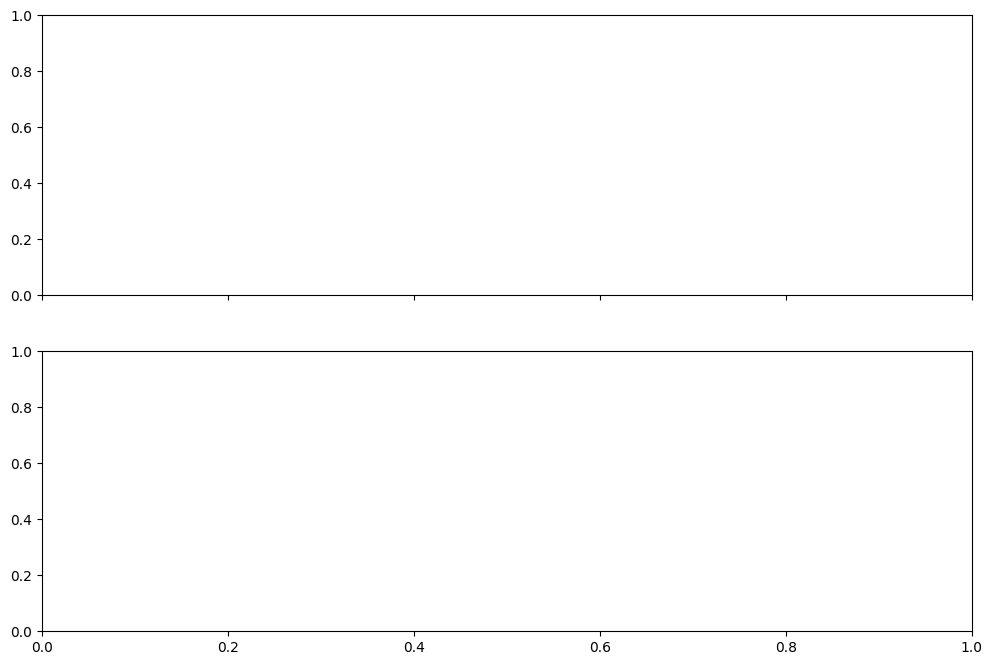

In [104]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), sharex="col")
plt_kwargs = dict(grid=True, marker='x')
hist[["train_loss", "val_loss"]].plot(ax=axs[0], **plt_kwargs)
hist[["val_cmi"]].plot(ax=axs[1], **plt_kwargs)
plt.show()

# Eval

In [109]:
torch.save(model.state_dict(), OUT_DIR / "lstm_weights_first.pth")

In [ ]:
model.load_state_dict(torch.load(path_model, weights_only=True))

<All keys matched successfully>

In [902]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

NameError: name 'predict' is not defined

In [ ]:
model.load_state_dict(torch.load(path_model_score, weights_only=True))

<All keys matched successfully>

In [84]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

0.3944116347311109